# Pizza Palace — Fine-tuning Qwen3-4B with Unsloth (QLoRA)
### From dataset → training → GGUF (Ollama) + merged 16-bit (vLLM)

**Runtime:** Colab → change runtime type → **T4 GPU** (free tier is enough for a 4B model with QLoRA).

This notebook does five things:
1. Install Unsloth and load **Qwen3-4B** in 4-bit (QLoRA).
2. Attach LoRA adapters (the tiny trainable side-matrices).
3. Load your `pizza_palace_400_train.jsonl` / `_val.jsonl` and apply Qwen3's chat template.
4. Train, watching **train vs. validation loss**.
5. Export to **GGUF for Ollama** and **merged 16-bit for vLLM**.

> Mental model recap: the base model stays **frozen**. We only train small LoRA matrices (rank `r`), scaled by `alpha`. QLoRA means the frozen base is quantized to 4-bit so it fits in a T4's ~15 GB.

## 1. Install
Unsloth pins compatible versions of transformers/trl/peft for you. Pin Unsloth itself if you want reproducibility across class sessions — APIs move fast.

In [7]:
# %%capture
!uv pip install -U unsloth unsloth_zoo
! uv pip install -q "datasets==3.6.0"
# If a class needs a frozen, reproducible setup, pin instead, e.g.:
# !pip install "unsloth==2026.5.*" "unsloth_zoo==2026.5.*"


Using Python 3.12.13 environment at: /usr
Resolved 101 packages in 621ms
Prepared 33 packages in 1.35s
Uninstalled 33 packages in 240ms
Installed 33 packages in 76ms
 - aiohttp==3.14.1
 + aiohttp==3.14.3
 - annotated-doc==0.0.4
 + annotated-doc==0.0.5
 - annotated-types==0.7.0
 + annotated-types==0.8.0
 - certifi==2026.6.17
 + certifi==2026.7.22
 - charset-normalizer==3.4.9
 + charset-normalizer==3.5.1
 - cuda-pathfinder==1.5.6
 + cuda-pathfinder==1.6.1
 - datasets==3.6.0
 + datasets==4.3.0
 - dill==0.3.8
 + dill==0.4.0
 - filelock==3.29.7
 + filelock==3.32.3
 - fsspec==2025.3.0
 + fsspec==2025.9.0
 - hf-xet==1.5.1
 + hf-xet==1.6.0
 - huggingface-hub==1.23.0
 + huggingface-hub==1.27.0
 - idna==3.18
 + idna==3.19
 - numpy==2.0.2
 + numpy==2.5.2
 - packaging==26.2
 + packaging==26.3
 - pandas==2.2.2
 + pandas==3.0.5
 - peft==0.19.1
 + peft==0.20.0
 - pillow==11.3.0
 + pillow==12.3.0
 - protobuf==5.29.6
 + protobuf==7.35.1
 - psutil==5.9.5
 + psutil==7.2.2
 - pygments==2.20.0
 + pygments=

## 2. Load Qwen3-4B in 4-bit

- `max_seq_length = 1024`: our records carry a system menu, so they run a little longer than a bare prompt. 1024 is comfortable headroom.
- `load_in_4bit = True`: this is the **Q** in QLoRA — the frozen base is stored in 4-bit, cutting VRAM to ~a quarter.
- `dtype = None`: let Unsloth pick (bfloat16 on newer GPUs, float16 on T4).

In [8]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 1024
dtype = None            # auto: bf16 where supported, else fp16
load_in_4bit = True     # QLoRA — 4-bit frozen base

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = "unsloth/Qwen3-4B",   # Unsloth's 4-bit-ready Qwen3-4B
    max_seq_length = max_seq_length,
    dtype          = dtype,
    load_in_4bit   = load_in_4bit,
    # full_finetuning = False,   # default; we're doing LoRA
)


==((====))==  Unsloth 2026.8.18: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

## 3. Attach LoRA adapters

This is where the trainable parameters come from. Everything else stays frozen.

- **`r` (rank) = 16** — capacity of the side-matrices. 8 is fine for pure style; 16 gives a little more room for the persona + "use the provided menu" behaviour. Bigger = more capacity + more params.
- **`lora_alpha` = 16** — the scaling on the LoRA update. A common rule is alpha ≈ rank (some use 2×rank). The **alpha/rank ratio** sets the real strength.
- **`target_modules`** — which weight matrices get adapters. We hit both attention (`q,k,v,o`) and the feed-forward (`gate,up,down`) projections — the standard "all-linear" LoRA that gives the best quality.
- **`use_gradient_checkpointing = "unsloth"`** — trades a little compute for a lot of memory, so longer context fits on a T4.

In [9]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,          # 0 is optimized in Unsloth
    bias = "none",             # optimized
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,        # try True later: scales alpha by 1/sqrt(r)
    loftq_config = None,
)


In [14]:
!uv pip install huggingface_hub

Using Python 3.12.13 environment at: /usr
Checked 1 package in 101ms


In [26]:
from huggingface_hub import HfApi

api = HfApi()

files = api.list_repo_files(
    repo_id="PMIndiaData/PMIndiaSum",
    repo_type="dataset"
)

for f in files:
    print(f)

.gitattributes
README.md
assamese-assamese/test.csv
assamese-assamese/train.csv
assamese-assamese/valid.csv
assamese-bengali/test.csv
assamese-bengali/train.csv
assamese-bengali/valid.csv
assamese-english/test.csv
assamese-english/train.csv
assamese-english/valid.csv
assamese-gujarati/test.csv
assamese-gujarati/train.csv
assamese-gujarati/valid.csv
assamese-hindi/test.csv
assamese-hindi/train.csv
assamese-hindi/valid.csv
assamese-kannada/test.csv
assamese-kannada/train.csv
assamese-kannada/valid.csv
assamese-malayalm/test.csv
assamese-malayalm/train.csv
assamese-malayalm/valid.csv
assamese-manipuri/test.csv
assamese-manipuri/train.csv
assamese-manipuri/valid.csv
assamese-marathi/test.csv
assamese-marathi/train.csv
assamese-marathi/valid.csv
assamese-odia/test.csv
assamese-odia/train.csv
assamese-odia/valid.csv
assamese-punjabi/test.csv
assamese-punjabi/train.csv
assamese-punjabi/valid.csv
assamese-tamil/test.csv
assamese-tamil/train.csv
assamese-tamil/valid.csv
assamese-telugu/test.csv

In [27]:
data_files = [
    f for f in files
    if f.endswith((".csv", ".json", ".jsonl", ".parquet"))
]

for f in data_files:
    print(f)

assamese-assamese/test.csv
assamese-assamese/train.csv
assamese-assamese/valid.csv
assamese-bengali/test.csv
assamese-bengali/train.csv
assamese-bengali/valid.csv
assamese-english/test.csv
assamese-english/train.csv
assamese-english/valid.csv
assamese-gujarati/test.csv
assamese-gujarati/train.csv
assamese-gujarati/valid.csv
assamese-hindi/test.csv
assamese-hindi/train.csv
assamese-hindi/valid.csv
assamese-kannada/test.csv
assamese-kannada/train.csv
assamese-kannada/valid.csv
assamese-malayalm/test.csv
assamese-malayalm/train.csv
assamese-malayalm/valid.csv
assamese-manipuri/test.csv
assamese-manipuri/train.csv
assamese-manipuri/valid.csv
assamese-marathi/test.csv
assamese-marathi/train.csv
assamese-marathi/valid.csv
assamese-odia/test.csv
assamese-odia/train.csv
assamese-odia/valid.csv
assamese-punjabi/test.csv
assamese-punjabi/train.csv
assamese-punjabi/valid.csv
assamese-tamil/test.csv
assamese-tamil/train.csv
assamese-tamil/valid.csv
assamese-telugu/test.csv
assamese-telugu/train.cs

In [28]:
from datasets import load_dataset

languages = [
    "english",
    "hindi",
    "telugu",
    "tamil",
    "bengali",
    "odia"
]

datasets = {}

for lang in languages:
    dataset_name = f"{lang}-{lang}"

    datasets[lang] = load_dataset(
        "csv",
        data_files={
            "train": f"hf://datasets/PMIndiaData/PMIndiaSum/{dataset_name}/train.csv",
            "validation": f"hf://datasets/PMIndiaData/PMIndiaSum/{dataset_name}/valid.csv",
            "test": f"hf://datasets/PMIndiaData/PMIndiaSum/{dataset_name}/test.csv",
        }
    )

    print(
        lang,
        len(datasets[lang]["train"]),
        len(datasets[lang]["validation"]),
        len(datasets[lang]["test"])
    )

english-english/train.csv: reconstructing file:   0%|          |  0.00B / 24.6MB            

english-english/train.csv: downloading bytes:           |  0.00B            

valid.csv:   0%|          | 0.00/233k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/244k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

test.csv:   0%|          | 0.00/590k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

odia 4419 116 116


In [29]:
for lang in languages:
    print("\n", lang)
    print(datasets[lang]["train"].column_names)
    print(datasets[lang]["train"][0])


 english
['source_url', 'target_url', 'text', 'summary']
{'source_url': 'https://www.pmindia.gov.in/en/news_updates/cabinet-approves-revamped-khelo-india-programme/', 'target_url': 'https://www.pmindia.gov.in/en/news_updates/cabinet-approves-revamped-khelo-india-programme/', 'text': 'The Union Cabinet chaired by the Prime Minister Shri Narendra Modi has approved the revamped Khelo India programme at a cost of Rs.1,756 crore for the period 2017-18 to 2019-20. This marks a watershed moment in the history of Indian sports, as the Programme aims at mainstreaming sport as a tool for individual development, community development, economic development and national development. The revamped Khelo India Programme would impact the entire sports ecosystem, including infrastructure, community sports, talent identification, coaching for excellence, competition structure and sports economy. Salient features: Some of the salient features of the Programme include: • an unprecedented Pan Indian Sports

In [30]:
def prepare_dataset(dataset, language):


    dataset = dataset.add_column(
        "language",
        [language] * len(dataset)
    )

    return dataset

In [31]:
for lang in languages:

    datasets[lang]["train"] = prepare_dataset(
        datasets[lang]["train"],
        lang
    )

    datasets[lang]["validation"] = prepare_dataset(
        datasets[lang]["validation"],
        lang
    )

    datasets[lang]["test"] = prepare_dataset(
        datasets[lang]["test"],
        lang
    )

In [32]:
from datasets import concatenate_datasets

train_dataset = concatenate_datasets([
    datasets["english"]["train"],
    datasets["hindi"]["train"],
    datasets["telugu"]["train"],
    datasets["tamil"]["train"],
    datasets["bengali"]["train"],
    datasets["odia"]["train"],
])

In [33]:
valid_dataset = concatenate_datasets([
    datasets["english"]["validation"],
    datasets["hindi"]["validation"],
    datasets["telugu"]["validation"],
    datasets["tamil"]["validation"],
    datasets["bengali"]["validation"],
    datasets["odia"]["validation"],
])

In [34]:
test_dataset = concatenate_datasets([
    datasets["english"]["test"],
    datasets["hindi"]["test"],
    datasets["telugu"]["test"],
    datasets["tamil"]["test"],
    datasets["bengali"]["test"],
    datasets["odia"]["test"],
])

In [35]:
from collections import Counter

print("TRAIN")
print(Counter(train_dataset["language"]))

print("\nVALIDATION")
print(Counter(valid_dataset["language"]))

print("\nTEST")
print(Counter(test_dataset["language"]))

TRAIN
Counter({'english': 7928, 'hindi': 7131, 'telugu': 5894, 'tamil': 5847, 'bengali': 5325, 'odia': 4419})

VALIDATION
Counter({'english': 116, 'hindi': 116, 'telugu': 116, 'tamil': 116, 'bengali': 116, 'odia': 116})

TEST
Counter({'english': 116, 'hindi': 116, 'telugu': 116, 'tamil': 116, 'bengali': 116, 'odia': 116})


In [36]:
print(train_dataset)

Dataset({
    features: ['source_url', 'target_url', 'text', 'summary', 'language'],
    num_rows: 36544
})


In [37]:
for i in range(3):
    print("\nLANGUAGE:", train_dataset[i]["language"])
    print("TEXT:", train_dataset[i]["text"][:500])
    print("SUMMARY:", train_dataset[i]["summary"])


LANGUAGE: english
TEXT: The Union Cabinet chaired by the Prime Minister Shri Narendra Modi has approved the revamped Khelo India programme at a cost of Rs.1,756 crore for the period 2017-18 to 2019-20. This marks a watershed moment in the history of Indian sports, as the Programme aims at mainstreaming sport as a tool for individual development, community development, economic development and national development. The revamped Khelo India Programme would impact the entire sports ecosystem, including infrastructure, com
SUMMARY: Cabinet approves Revamped Khelo India Programme

LANGUAGE: english
TEXT: The Prime Minister, Shri Narendra Modi has congratulated Suhas Yathiraj for winning Silver medal in Badminton at the Paralympics Games in Tokyo. In a tweet, the Prime Minister said; “A fantastic confluence of service and sports! @dmgbnagar Suhas Yathiraj has captured the imagination of our entire nation thanks to his exceptional sporting performance. Congratulations to him on winning the S

In [38]:
print(datasets["english"]["train"].column_names)
print(datasets["english"]["train"][0])

print(datasets["odia"]["train"].column_names)
print(datasets["odia"]["train"][0])

['source_url', 'target_url', 'text', 'summary', 'language']
{'source_url': 'https://www.pmindia.gov.in/en/news_updates/cabinet-approves-revamped-khelo-india-programme/', 'target_url': 'https://www.pmindia.gov.in/en/news_updates/cabinet-approves-revamped-khelo-india-programme/', 'text': 'The Union Cabinet chaired by the Prime Minister Shri Narendra Modi has approved the revamped Khelo India programme at a cost of Rs.1,756 crore for the period 2017-18 to 2019-20. This marks a watershed moment in the history of Indian sports, as the Programme aims at mainstreaming sport as a tool for individual development, community development, economic development and national development. The revamped Khelo India Programme would impact the entire sports ecosystem, including infrastructure, community sports, talent identification, coaching for excellence, competition structure and sports economy. Salient features: Some of the salient features of the Programme include: • an unprecedented Pan Indian Spor

In [25]:
# from datasets import load_dataset

# # english = load_dataset(
# #     "PMIndiaData/PMIndiaSum",
# #     "english"
# # )

# hindi = load_dataset(
#     "PMIndiaData/PMIndiaSum",
#     "hindi"
# )

# telugu = load_dataset(
#     "PMIndiaData/PMIndiaSum",
#     "telugu"
# )

# tamil = load_dataset(
#     "PMIndiaData/PMIndiaSum",
#     "tamil"
# )

# bengali = load_dataset(
#     "PMIndiaData/PMIndiaSum",
#     "bengali"
# )

# odia = load_dataset(
#     "PMIndiaData/PMIndiaSum",
#     "odia"
# )

ValueError: BuilderConfig 'hindi' not found. Available: ['assamese-assamese']

In [21]:
    # from huggingface_hub import HfApi

    # api = HfApi()

    # files = api.list_repo_files(
    #     repo_id="GEM/xlsum",
    #     repo_type="dataset",
    # )

    # parquet_files = [
    #     f for f in files
    #     if f.endswith(".parquet")
    # ]

    # for f in parquet_files:
    #     print(f)

In [22]:
# from huggingface_hub import hf_hub_url
# from datasets import load_dataset

# languages = [
#     "english",
#     "hindi",
#     "telugu",
#     "tamil",
#     "bengali",
# ]

# train_datasets = {}

# for language in languages:

#     language_files = [
#         f for f in parquet_files
#         if f.startswith(f"{language}/")
#         and "train" in f
#     ]

#     print(f"\n{language}:")
#     print(language_files)

#     urls = [
#         hf_hub_url(
#             repo_id="GEM/xlsum",
#             filename=f,
#             repo_type="dataset"
#         )
#         for f in language_files
#     ]

#     train_datasets[language] = load_dataset(
#         "parquet",
#         data_files=urls,
#         split="train"
#     )

#     print(len(train_datasets[language]))


english:
[]


ValueError: Empty 'data_files': '[]'. It should be either non-empty or None (default).

In [18]:
# from datasets import load_dataset, concatenate_datasets

# BASE_URL = "https://huggingface.co/datasets/GEM/xlsum/resolve/main"

# languages = {
#     "english": "english/xlsum-train.parquet",
#     "hindi": "hindi/xlsum-train-00000-of-00002.parquet",
#     "telugu": "telugu/xlsum-train.parquet",
#     "tamil": "tamil/xlsum-train.parquet",
#     "bengali": "bengali/xlsum-train.parquet",
#     "odia": "odia/xlsum-train.parquet",
# }

In [19]:
# datasets = {}

# for language, file_path in languages.items():
#     url = f"{BASE_URL}/{file_path}"

#     datasets[language] = load_dataset(
#         "parquet",
#         data_files=url,
#         split="train"
#     )

#     print(
#         f"{language}: {len(datasets[language])} examples"
#     )
#   print(datasets.keys())

FileNotFoundError: Unable to find 'hf://datasets/GEM/xlsum@main/english/xlsum-train.parquet'

## 4. Bring in your dataset

Upload `pizza_palace_400_train.jsonl` and `pizza_palace_400_val.jsonl` (left sidebar → Files → upload), or pull them from Google Drive / HF. Each line is already in the `messages` format:

```json
{"messages":[{"role":"system","content":"...menu..."},
             {"role":"user","content":"veg pizza?"},
             {"role":"assistant","content":"Hey there, welcome to Pizza Palace! ..."}]}
```

In [42]:
from datasets import load_dataset, concatenate_datasets

# english = load_dataset("GEM/xlsum", "english")
# hindi = load_dataset("GEM/xlsum", "hindi")
# telugu = load_dataset("GEM/xlsum", "telugu")
# tamil = load_dataset("GEM/xlsum", "tamil")
# bengali = load_dataset("GEM/xlsum", "bengali")
# odia = load_dataset("GEM/xlsum", "odia")

# # Combine the existing TRAIN splits
# combined = concatenate_datasets([
#     english["train"],
#     hindi["train"],
#     telugu["train"],
#     tamil["train"],
#     bengali["train"],
#     odia["train"],
# ])

# # Create 80:20 train/validation split
# split_dataset = combined.train_test_split(
#     test_size=0.20,
#     seed=42
# )

# train_dataset = split_dataset["train"]
# valid_dataset = split_dataset["test"]

print("Train:", len(train_dataset))
print("Validation:", len(valid_dataset))

def word_count(text):
    return len(text.split())
def valid_example(example):
    count = word_count(example["summary"])
    return 40 <= count <= 45

# filtered = combined["train"].filter(valid_example)


Train: 36544
Validation: 696


### Apply Qwen3's chat template

Qwen3 uses **ChatML** under the hood (`<|im_start|>` / `<|im_end|>`). You don't write those tokens — you hand Unsloth the clean `messages` list and let `get_chat_template` + `apply_chat_template` wrap each conversation into the exact string Qwen3 was trained on.

`enable_thinking=False` keeps the empty `<think></think>` block out of training targets — for a support-agent persona we want direct replies, not reasoning traces.

In [43]:
from unsloth.chat_templates import get_chat_template

# Qwen3 tokenizer
tokenizer = get_chat_template(
    tokenizer,
    chat_template="qwen3"
)


def format_chat(examples):

    messages_batch = []

    for text, summary, language in zip(
        examples["text"],
        examples["summary"],
        examples["language"]
    ):

        messages = [
            {
                "role": "user",
                "content": (
                    f"Summarize the following news in 40-45 words "
                    f"in {language}.\n\n"
                    f"News:\n{text}"
                )
            },
            {
                "role": "assistant",
                "content": summary
            }
        ]

        messages_batch.append(messages)

    formatted_texts = [
        tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False,
        )
        for messages in messages_batch
    ]

    return {
        "text": formatted_texts
    }


train_dataset = train_dataset.map(
    format_chat,
    batched=True
)

val_dataset = valid_dataset.map(
    format_chat,
    batched=True
)

print(train_dataset[0]["text"][:1000])

Map:   0%|          | 0/36544 [00:00<?, ? examples/s]

<|im_start|>user
Summarize the following news in 40-45 words in english.

News:
<|im_start|>user
Summarize the following news in 40-45 words in english.

News:
The Union Cabinet chaired by the Prime Minister Shri Narendra Modi has approved the revamped Khelo India programme at a cost of Rs.1,756 crore for the period 2017-18 to 2019-20. This marks a watershed moment in the history of Indian sports, as the Programme aims at mainstreaming sport as a tool for individual development, community development, economic development and national development. The revamped Khelo India Programme would impact the entire sports ecosystem, including infrastructure, community sports, talent identification, coaching for excellence, competition structure and sports economy. Salient features: Some of the salient features of the Programme include: • an unprecedented Pan Indian Sports Scholarship scheme, which would cover 1,000 most talented young athletes each year across select sports disciplines. • Each a

## 5. Trainer configuration

Every hyperparameter here maps to something we discussed:

- **`learning_rate = 2e-4`** — step size per weight update. LoRA's sweet spot. Loss jittering → lower it; barely moving → raise it.
- **`per_device_train_batch_size = 2` × `gradient_accumulation_steps = 4`** → **effective batch size 8**. The T4 can't hold 8 at once, so we accumulate 4 micro-batches of 2 and apply one combined update — big-batch stability, small-batch memory.
- **`num_train_epochs = 3`** — with ~352 rows, 2–3 passes is the sweet spot; more risks memorizing.
- **`eval_strategy = "steps"`** — this is what lets you *watch* train vs. val loss diverge (the overfitting fingerprint).
- **`warmup_steps`** — ramp the LR up gently so early updates don't thrash the weights.

In [44]:
from trl import SFTTrainer, SFTConfig
train_small = train_dataset.shuffle(seed=42).select(
    range(min(3000, len(train_dataset)))
)

val_small = val_dataset.shuffle(seed=42).select(
    range(min(500, len(val_dataset)))
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_small,
    # train_dataset = train_dataset,
    # eval_dataset = val_dataset,
    eval_dataset = val_small,
    args = SFTConfig(
        dataset_text_field = "text",
        max_seq_length = max_seq_length,
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 4,     # effective batch = 8
        warmup_steps = 5,
        num_train_epochs = 1,
        # num_train_epochs = 3,
        learning_rate = 2e-4,
        logging_steps = 15,
        eval_strategy = "steps",
        eval_steps = 120,                     # check val loss every 20 steps
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",

        eval_strategy="steps",
        eval_steps=100,

        save_strategy="steps",
        save_steps=100,

        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
    ),
)


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/36544 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/696 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


### Train only on the assistant's replies

Crucial for instruction tuning: we don't want the model spending capacity learning to *predict the customer's message or the menu*. `train_on_responses_only` masks the loss so gradients flow **only** from the assistant turns. For Qwen3/ChatML the turn markers are `<|im_start|>user\n` and `<|im_start|>assistant\n`.

In [ ]:
from transformers import EarlyStoppingCallback

trainer.add_callback(
    EarlyStoppingCallback(
        early_stopping_patience=2
    )
)

In [45]:
from unsloth.chat_templates import train_on_responses_only

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part    = "<|im_start|>assistant\n",
)


Map (num_proc=2):   0%|          | 0/36544 [00:00<?, ? examples/s]

Filter (num_proc=2):   0%|          | 0/36544 [00:00<?, ? examples/s]

Unsloth: Removed 19308 out of 36544 samples from train_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.


Map (num_proc=2):   0%|          | 0/696 [00:00<?, ? examples/s]

Filter (num_proc=2):   0%|          | 0/696 [00:00<?, ? examples/s]

Unsloth: Removed 390 out of 696 samples from eval_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.


### Go

In [46]:
trainer_stats = trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 17,236 | Num Epochs = 3 | Total steps = 6,465
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
20,0.174092,0.352456
40,0.141256,0.296126
60,0.115907,0.282810
80,0.144399,0.266339


Filter:   0%|          | 0/306 [00:00<?, ? examples/s]

KeyboardInterrupt: 

In [47]:
print(trainer.state.global_step)

80


### Read the curves
Pull the logged history and plot **training vs. validation loss**. Healthy = both descend and stay close. The moment val flattens/rises while train keeps dropping → overfitting → stop or reduce epochs/rank. Great live demo for the class.

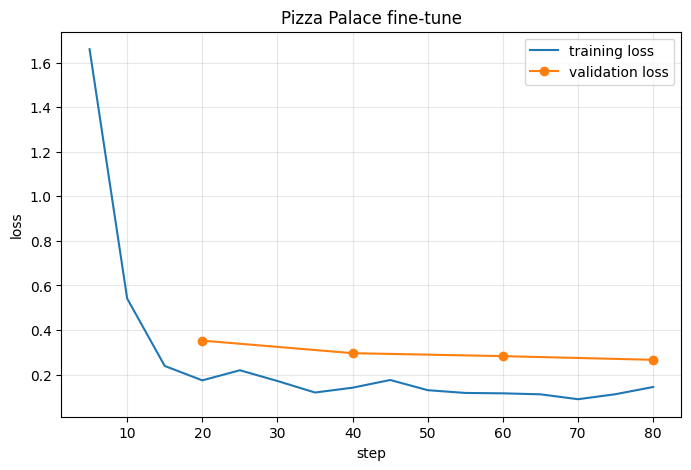

In [48]:
import matplotlib.pyplot as plt

hist = trainer.state.log_history
tr = [(h["step"], h["loss"])      for h in hist if "loss" in h]
ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

plt.figure(figsize=(8,5))
if tr: plt.plot(*zip(*tr), label="training loss")
if ev: plt.plot(*zip(*ev), label="validation loss", marker="o")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("Pizza Palace fine-tune"); plt.grid(True, alpha=.3)
plt.show()


## 6. Quick sanity test (before export)
Switch to fast inference and talk to the model. Does it sound like Pizza Palace?

In [ ]:
FastLanguageModel.for_inference(model)

messages = [
    {
        "role": "system",
        "content": (
            "You are a multilingual news summarization assistant. "
            "Summarize accurately without adding information."
        )
    },
    {
        "role": "user",
        "content": """
Language: Odia

Summarize the following news in approximately 40-45 words.

News:
The Government of India today announced a new agricultural
scheme to provide financial assistance and modern equipment
to farmers. The scheme will be implemented across several
states from next month.
"""
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    enable_thinking=False,
).to("cuda")

out = model.generate(
    input_ids=inputs,
    max_new_tokens=100,
    temperature=0.3,
    top_p=0.9,
)

response = tokenizer.decode(
    out[0][inputs.shape[-1]:],
    skip_special_tokens=True
).strip()

print(response)
print("Words:", len(response.split()))

In [49]:
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

messages = [
    {
        "role": "system",
        "content": (
            "You are a multilingual news summarization assistant. "
            "Summarize news accurately and concisely. "
            "Generate approximately 40-45 words. "
            "Do not add information that is not present in the news."
        )
    },
    {
        "role": "user",
        "content": """Language: Telugu

Summarize the following news in approximately 40-45 words.

News:
ఆంధ్రప్రదేశ్ ప్రభుత్వం రాష్ట్రంలోని రైతులకు కొత్త పథకాన్ని ప్రకటించింది. "
ఈ పథకం ద్వారా రైతులకు వ్యవసాయ పరికరాలు, విత్తనాలు మరియు సబ్సిడీ అందించనున్నట్లు అధికారులు తెలిపారు. "
రాబోయే నెల నుంచి ఈ పథకం అమలు కానుంది."""
    },
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    enable_thinking=False,
).to("cuda")

out = model.generate(
    input_ids=inputs,
    max_new_tokens=100,
    temperature=0.3,
    top_p=0.9,
)

response = tokenizer.decode(
    out[0][inputs.shape[-1]:],
    skip_special_tokens=True
)

print(response)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=100) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ఆంధ్రప్రదేశ్ రైతులకు కొత్త పథకాన్ని ప్రకటించింది


In [ ]:
# FastLanguageModel.for_inference(model)

# messages = [
#     {"role": "system", "content": "You are a warm, upbeat Pizza Palace support agent. Today's menu:\nMargherita ₹210\nPaneer Supreme ₹330\nGarlic Breadsticks ₹120\nCola ₹60\nUse ONLY this menu."},
#     {"role": "user", "content": "hey do u have anything veg"},
# ]
# # inputs = tokenizer.apply_chat_template(
#     messages, tokenize=True, add_generation_prompt=True,
#     return_tensors="pt", enable_thinking=False,
# ).to("cuda")

# out = model.generate(input_ids=inputs, max_new_tokens=128, temperature=0.7, top_p=0.9)
# print(tokenizer.decode(out[0], skip_special_tokens=True))


In [50]:
FastLanguageModel.for_inference(model)

messages = [
    {
        "role": "system",
        "content": (
            "You are a multilingual news summarization assistant. "
            "Summarize accurately without adding information."
        )
    },
    {
        "role": "user",
        "content": """
Language: Odia

Summarize the following news in approximately 40-45 words.

News:
The Government of India today announced a new agricultural
scheme to provide financial assistance and modern equipment
to farmers. The scheme will be implemented across several
states from next month.
"""
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    enable_thinking=False,
).to("cuda")

out = model.generate(
    input_ids=inputs,
    max_new_tokens=100,
    temperature=0.3,
    top_p=0.9,
)

response = tokenizer.decode(
    out[0][inputs.shape[-1]:],
    skip_special_tokens=True
).strip()

print(response)
print("Words:", len(response.split()))

Both `max_new_tokens` (=100) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ନିଜାରାଜ୍ୟରେ କୃଷିକରୁ କମ୍ପାନୀରୁ କମ୍ପାନୀରୁ କମ୍ପାନ
Words: 5


In [ ]:
FastLanguageModel.for_inference(model)

news = """
The Government of India today announced a new initiative to support
farmers across the country. The programme will provide financial
assistance, modern agricultural equipment and improved access to
quality seeds. Officials said the scheme will be implemented from
next month.
"""

languages = [
    "English",
    "Hindi",
    "Telugu",
    "Tamil",
    "Bengali",
    "Odia",
]

for language in languages:

    messages = [
        {
            "role": "system",
            "content": (
                "You are a multilingual news summarization assistant. "
                "Summarize only the information provided. "
                "Do not hallucinate or add facts."
            )
        },
        {
            "role": "user",
            "content": f"""
Language: {language}

Summarize the following news in approximately 40-45 words.

News:
{news}
"""
        },
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        enable_thinking=False,
    ).to("cuda")

    out = model.generate(
        input_ids=inputs,
        max_new_tokens=100,
        temperature=0.3,
        top_p=0.9,
    )

    response = tokenizer.decode(
        out[0][inputs.shape[-1]:],
        skip_special_tokens=True
    )

    print("=" * 70)
    print(f"LANGUAGE: {language}")
    print(response)

## 7. Save the LoRA adapters (lightweight checkpoint)
Just the adapters — a few MB. Useful to keep, and to re-merge later without retraining.

In [ ]:
model.save_pretrained("pizza_lora")          # local
tokenizer.save_pretrained("pizza_lora")
# model.push_to_hub("your-username/pizza-qwen3-lora", token="hf_...")   # optional


## 8. Export → GGUF for **Ollama**

`save_pretrained_gguf` merges the LoRA into the base, converts to GGUF via llama.cpp, and quantizes. Pick a quant:
- **`q4_k_m`** — best size/quality trade-off, the usual choice for laptops/edge.
- **`q8_0`** — larger, higher fidelity.
- **`f16`** — full precision GGUF (biggest).

This step compiles llama.cpp the first time, so give it a few minutes.

In [ ]:
model.save_pretrained_gguf(
    "pizza_gguf",
    tokenizer,
    quantization_method = "q4_k_m",   # try "q8_0" for higher fidelity
)
# Produces e.g. pizza_gguf/unsloth.Q4_K_M.gguf
!ls -lh pizza_gguf


### Run it in Ollama
Unsloth writes a `Modelfile` next to the GGUF with the correct Qwen3 chat template baked in. Two ways to use it:

**A) On a machine with Ollama installed** (your GCP L4 VM, or locally): download the `.gguf` + `Modelfile`, then:
```bash
ollama create pizza-palace -f Modelfile
ollama run pizza-palace
```

**B) Inside Colab** (to demo end-to-end):

In [ ]:
# Install + start Ollama inside Colab (demo only)
!curl -fsSL https://ollama.com/install.sh | sh
import subprocess, time
subprocess.Popen(["ollama", "serve"])
time.sleep(5)

# Unsloth auto-generates a Modelfile; if you need one manually, this works too:
modelfile = '''FROM ./pizza_gguf/unsloth.Q4_K_M.gguf
TEMPLATE """{{ if .System }}<|im_start|>system
{{ .System }}<|im_end|>
{{ end }}{{ if .Prompt }}<|im_start|>user
{{ .Prompt }}<|im_end|>
{{ end }}<|im_start|>assistant
{{ .Response }}<|im_end|>
"""
PARAMETER stop "<|im_end|>"
PARAMETER temperature 0.7
'''
open("pizza_gguf/Modelfile", "w").write(modelfile)

!cd pizza_gguf && ollama create pizza-palace -f Modelfile
!ollama run pizza-palace "hey do you have veg pizza?"


## 9. Export → merged 16-bit for **vLLM**

vLLM serves standard HF safetensors, **not** GGUF. So we merge the LoRA into the base at 16-bit precision with `save_method="merged_16bit"`. (`merged_4bit` also exists if you want a smaller, lower-fidelity artifact.)

In [ ]:
model.save_pretrained_merged(
    "pizza_merged_16bit",
    tokenizer,
    save_method = "merged_16bit",
)
!ls -lh pizza_merged_16bit
# Optional straight-to-Hub:
# model.push_to_hub_merged("your-username/pizza-qwen3", tokenizer, save_method="merged_16bit", token="hf_...")


### Serve with vLLM
On your GPU box (L4/A100), point vLLM at the merged folder:
```bash
pip install vllm
python -m vllm.entrypoints.openai.api_server \
    --model /path/to/pizza_merged_16bit \
    --served-model-name pizza-palace \
    --max-model-len 1024
```
Then it speaks the OpenAI API:
```bash
curl http://localhost:8000/v1/chat/completions -H "Content-Type: application/json" -d '{
  "model": "pizza-palace",
  "messages": [
    {"role":"system","content":"You are a Pizza Palace agent. Menu: Margherita ₹210, Cola ₹60. Use only this menu."},
    {"role":"user","content":"veg options?"}
  ]
}'
```

## 10. Get your files out of Colab
Zip and download, or push to Drive.

In [ ]:
from google.colab import files
!zip -r pizza_gguf.zip pizza_gguf
!zip -r pizza_merged_16bit.zip pizza_merged_16bit
files.download("pizza_gguf.zip")
# files.download("pizza_merged_16bit.zip")   # large — Drive is usually better


---
### Recap: which artifact for what
| Target | Method | Output | Serve with |
|---|---|---|---|
| **Ollama / laptop / edge** | `save_pretrained_gguf(..., "q4_k_m")` | `.gguf` + `Modelfile` | `ollama create` / `ollama run` |
| **vLLM / GPU serving** | `save_pretrained_merged(..., "merged_16bit")` | HF safetensors folder | `vllm ... --model <folder>` |
| **Re-use / re-merge later** | `save_pretrained("pizza_lora")` | LoRA adapters (MB) | reload + merge |

**Teaching note:** GGUF is quantized-for-CPU/edge; the vLLM path stays 16-bit for GPU throughput. Same fine-tune, two deployment targets — a clean way to show students that *training* and *serving format* are separate decisions.